# Leaf Disease Spot Segmentation

### Digital Image Processing Mini Project
**Dataset:** PlantVillage Tomato Early Blight
**Number of Images:** 120

Import Libraries and Connect Google Drive

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

from google.colab import drive

drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


Load and Display Original Images

Total images: 120


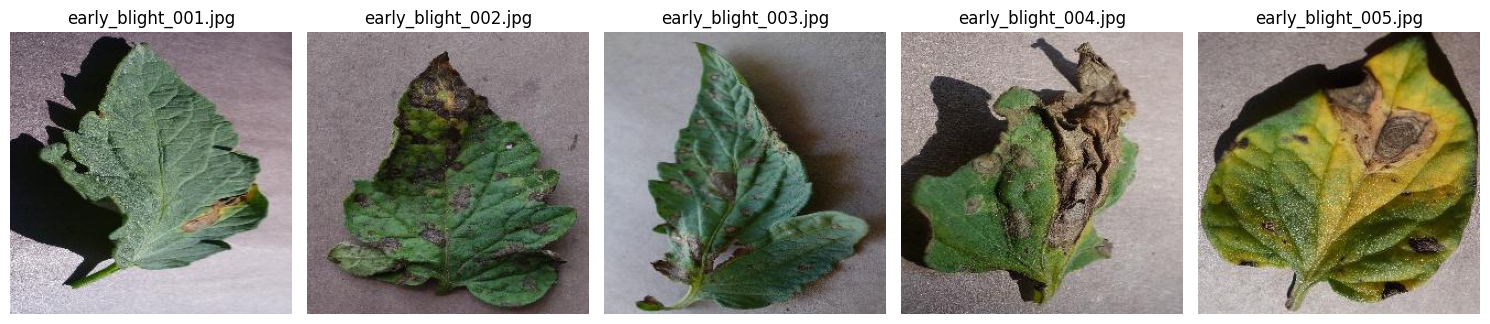

In [5]:
import cv2
import matplotlib.pyplot as plt
import os

# Dataset folder
folder = "/content/gdrive/MyDrive/Leaf_Disease_Segmentation/Dataset/Tomato_Early_Blight"

# Get all JPG images
images = sorted([
    file for file in os.listdir(folder)
    if file.lower().endswith(".jpg")
])

print("Total images:", len(images))

# Display first 5 images
plt.figure(figsize=(15, 8))

for i in range(5):

    image_path = os.path.join(
        folder,
        images[i]
    )

    image = cv2.imread(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(images[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

Image Preprocessing + RGB → HSV

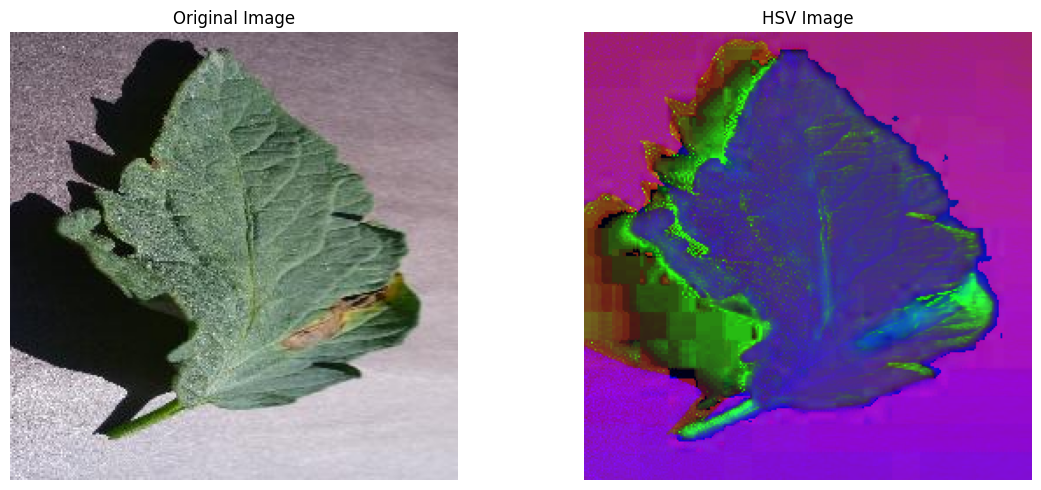

In [6]:
# Select one image
image_path = os.path.join(
    folder,
    "early_blight_001.jpg"
)

# Read image
image = cv2.imread(image_path)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

# Convert RGB to HSV
hsv_image = cv2.cvtColor(
    image_rgb,
    cv2.COLOR_RGB2HSV
)

# Display original and HSV images
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hsv_image)
plt.title("HSV Image")
plt.axis("off")

plt.tight_layout()
plt.show()

HSV Thresholding

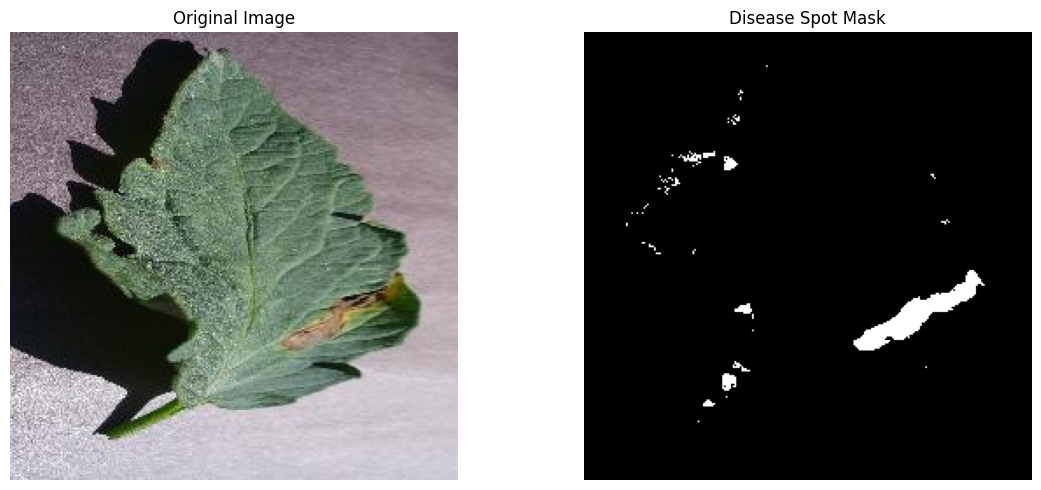

In [7]:
# Define HSV threshold range
lower = np.array([5, 40, 20])
upper = np.array([35, 255, 220])

# Create binary disease spot mask
mask = cv2.inRange(
    hsv_image,
    lower,
    upper
)

# Display original image and mask
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Disease Spot Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

Morphological Operations for Noise Removal

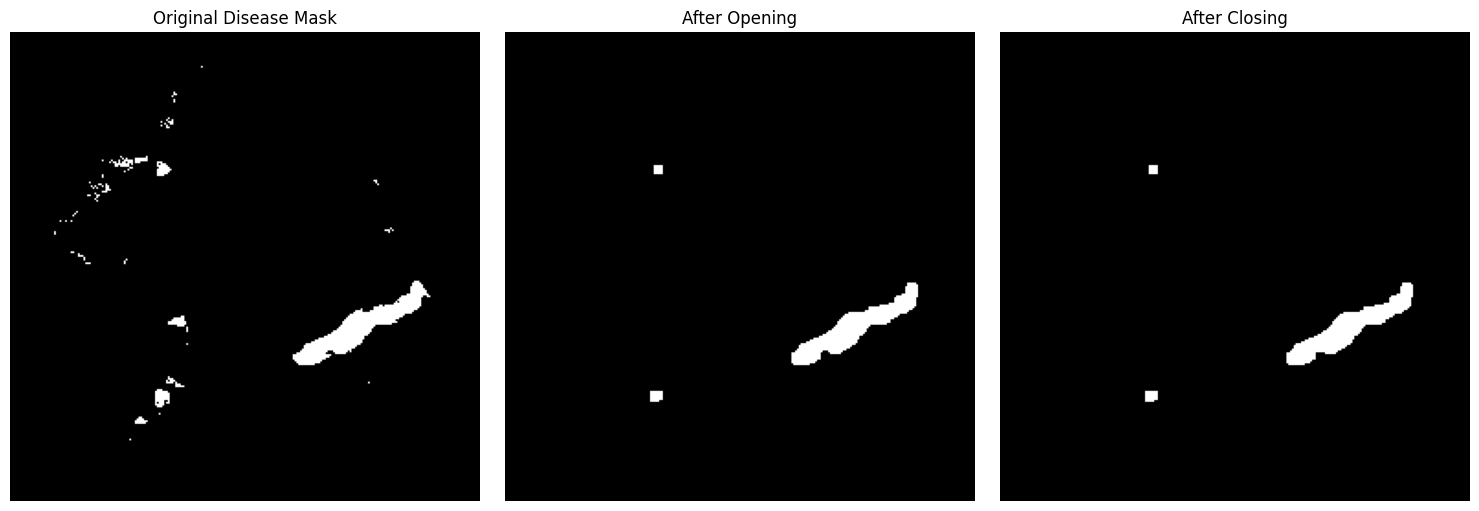

In [8]:
# Create morphological kernel
kernel = np.ones(
    (5, 5),
    np.uint8
)

# Remove small noise using opening
opening = cv2.morphologyEx(
    mask,
    cv2.MORPH_OPEN,
    kernel
)

# Fill small gaps using closing
clean_mask = cv2.morphologyEx(
    opening,
    cv2.MORPH_CLOSE,
    kernel
)

# Display the results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(mask, cmap="gray")
plt.title("Original Disease Mask")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(opening, cmap="gray")
plt.title("After Opening")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(clean_mask, cmap="gray")
plt.title("After Closing")
plt.axis("off")

plt.tight_layout()
plt.show()

Disease Spot Segmentation

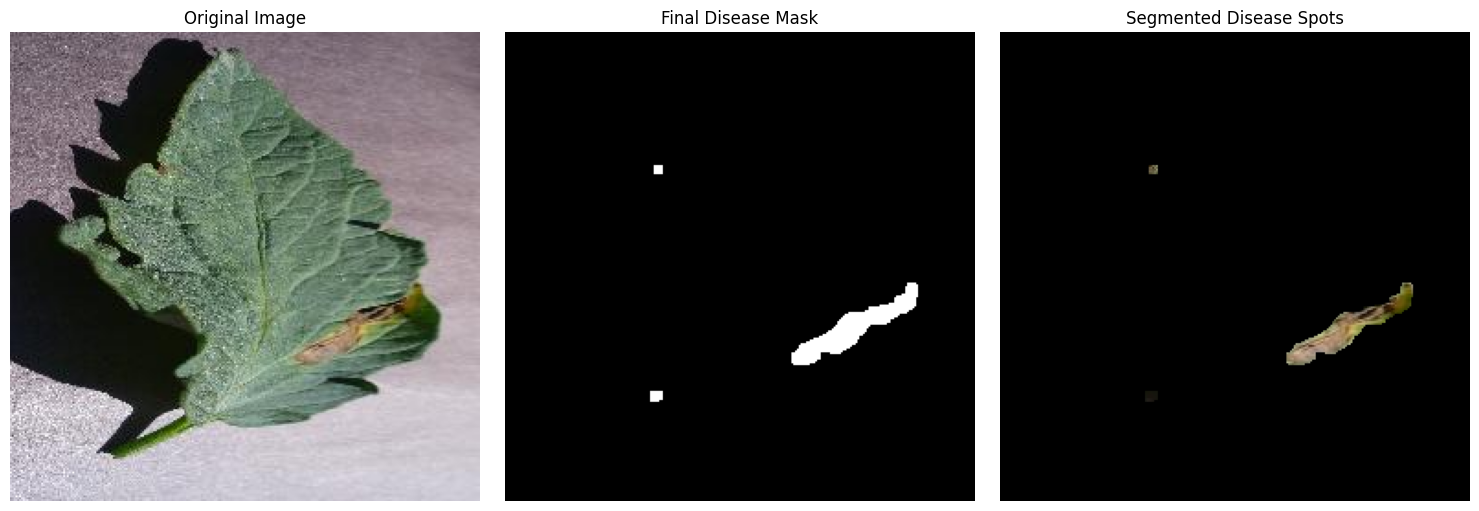

In [9]:
# Apply the disease mask to the original image
segmented_image = cv2.bitwise_and(
    image_rgb,
    image_rgb,
    mask=clean_mask
)

# Display the results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(clean_mask, cmap="gray")
plt.title("Final Disease Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(segmented_image)
plt.title("Segmented Disease Spots")
plt.axis("off")

plt.tight_layout()
plt.show()

Segmentation of All 120 Images

In [10]:
# Dataset folder
input_folder = "/content/gdrive/MyDrive/Leaf_Disease_Segmentation/Dataset/Tomato_Early_Blight"

# Result folders
mask_folder = "/content/gdrive/MyDrive/Leaf_Disease_Segmentation/Results/Masks"
segmented_folder = "/content/gdrive/MyDrive/Leaf_Disease_Segmentation/Results/Segmented"

# Create result folders if they don't exist
os.makedirs(
    mask_folder,
    exist_ok=True
)

os.makedirs(
    segmented_folder,
    exist_ok=True
)

# Get all JPG images
image_files = sorted([
    file for file in os.listdir(input_folder)
    if file.lower().endswith(".jpg")
])

# HSV threshold values
lower = np.array([5, 40, 20])
upper = np.array([35, 255, 220])

# Morphological kernel
kernel = np.ones(
    (5, 5),
    np.uint8
)

# Process every image
for file in image_files:

    image = cv2.imread(
        os.path.join(
            input_folder,
            file
        )
    )

    # Convert image to HSV
    hsv = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2HSV
    )

    # Create disease mask
    mask = cv2.inRange(
        hsv,
        lower,
        upper
    )

    # Morphological opening
    opening = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel
    )

    # Morphological closing
    clean_mask = cv2.morphologyEx(
        opening,
        cv2.MORPH_CLOSE,
        kernel
    )

    # Apply mask to original image
    segmented = cv2.bitwise_and(
        image,
        image,
        mask=clean_mask
    )

    # Save mask
    cv2.imwrite(
        os.path.join(
            mask_folder,
            file
        ),
        clean_mask
    )

    # Save segmented image
    cv2.imwrite(
        os.path.join(
            segmented_folder,
            file
        ),
        segmented
    )

print("Processing completed!")
print("Total images processed:", len(image_files))
print("Masks saved to:", mask_folder)
print("Segmented images saved to:", segmented_folder)

Processing completed!
Total images processed: 120
Masks saved to: /content/gdrive/MyDrive/Leaf_Disease_Segmentation/Results/Masks
Segmented images saved to: /content/gdrive/MyDrive/Leaf_Disease_Segmentation/Results/Segmented


Final Result Visualization

Selected images:
early_blight_001.jpg
early_blight_020.jpg
early_blight_050.jpg
early_blight_080.jpg
early_blight_100.jpg


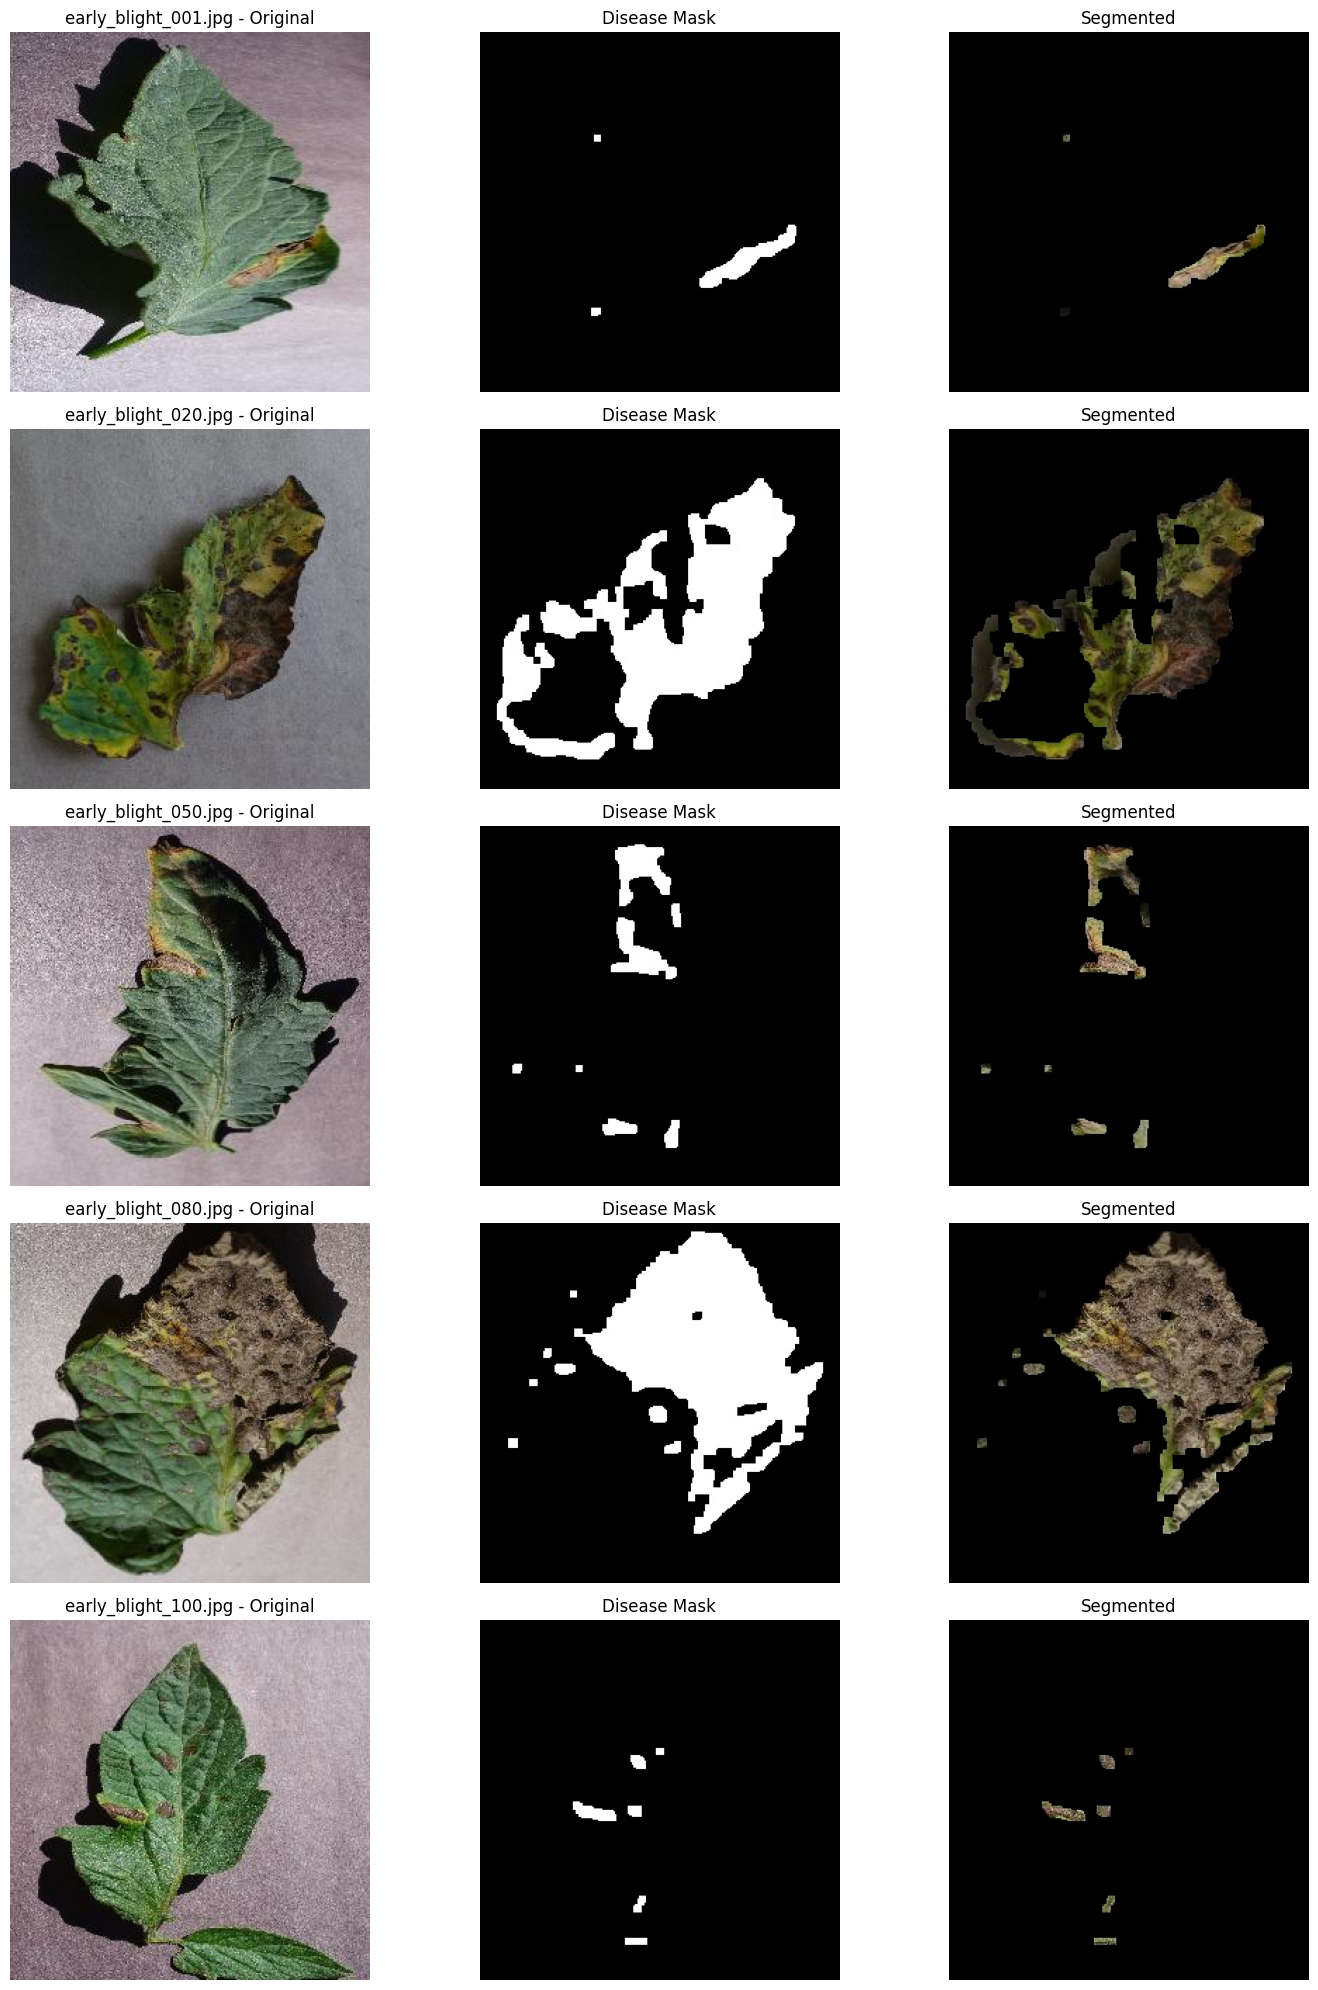

In [12]:
# Dataset folder
input_folder = "/content/gdrive/MyDrive/Leaf_Disease_Segmentation/Dataset/Tomato_Early_Blight"

# Result folders
mask_folder = "/content/gdrive/MyDrive/Leaf_Disease_Segmentation/Results/Masks"
segmented_folder = "/content/gdrive/MyDrive/Leaf_Disease_Segmentation/Results/Segmented"

# Get all available images
images = sorted([
    file for file in os.listdir(input_folder)
    if file.lower().endswith(".jpg")
])

# Select 5 images from the dataset
samples = [
    images[0],
    images[19],
    images[49],
    images[79],
    images[99]
]

print("Selected images:")
for file in samples:
    print(file)

# Display results
plt.figure(figsize=(15, 20))

for row, filename in enumerate(samples):

    # Read original image
    original = cv2.imread(
        os.path.join(input_folder, filename)
    )

    original = cv2.cvtColor(
        original,
        cv2.COLOR_BGR2RGB
    )

    # Read disease mask
    mask = cv2.imread(
        os.path.join(mask_folder, filename),
        cv2.IMREAD_GRAYSCALE
    )

    # Read segmented image
    segmented = cv2.imread(
        os.path.join(segmented_folder, filename)
    )

    segmented = cv2.cvtColor(
        segmented,
        cv2.COLOR_BGR2RGB
    )

    # Original image
    plt.subplot(5, 3, row * 3 + 1)
    plt.imshow(original)
    plt.title(filename + " - Original")
    plt.axis("off")

    # Disease mask
    plt.subplot(5, 3, row * 3 + 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Disease Mask")
    plt.axis("off")

    # Segmented image
    plt.subplot(5, 3, row * 3 + 3)
    plt.imshow(segmented)
    plt.title("Segmented")
    plt.axis("off")

plt.tight_layout()
plt.show()

HSV Parameter Comparison

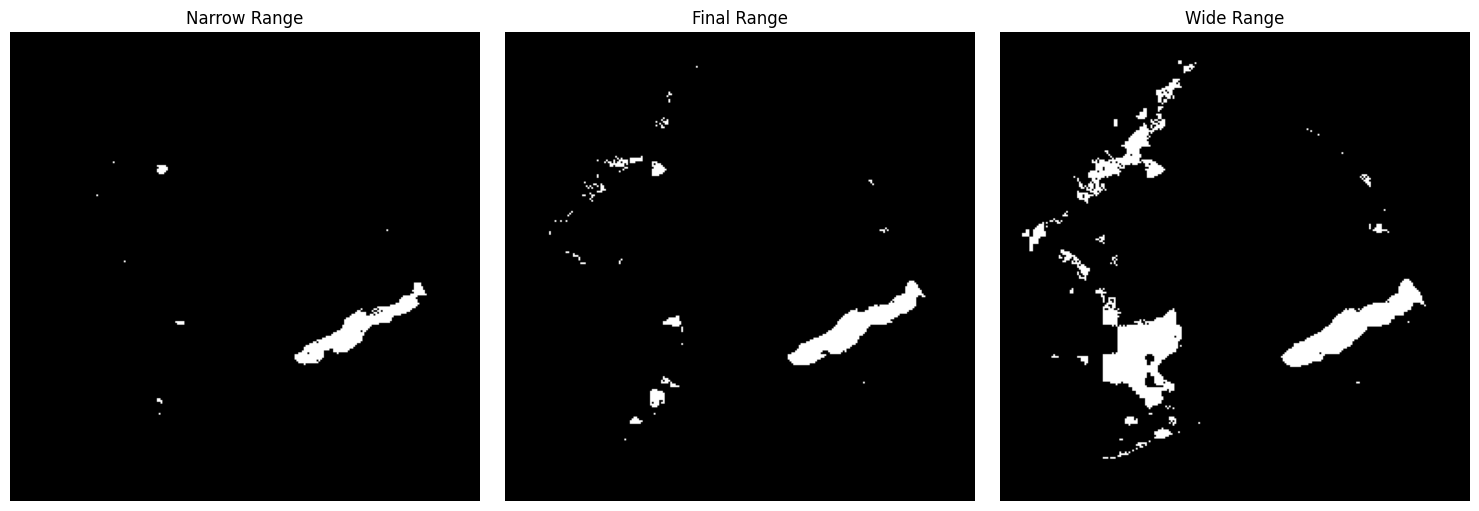

In [13]:
# HSV Parameter Comparison

# Select one representative image
comparison_file = "early_blight_001.jpg"

# Read image
image = cv2.imread(
    os.path.join(
        input_folder,
        comparison_file
    )
)

# Convert image to HSV
hsv = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2HSV
)

# Define three HSV threshold ranges
ranges = [
    (
        "Narrow Range",
        np.array([8, 50, 30]),
        np.array([30, 255, 210])
    ),
    (
        "Final Range",
        np.array([5, 40, 20]),
        np.array([35, 255, 220])
    ),
    (
        "Wide Range",
        np.array([0, 30, 15]),
        np.array([40, 255, 235])
    )
]

# Display comparison
plt.figure(figsize=(15, 5))

for i, (title, lower, upper) in enumerate(ranges):

    comparison_mask = cv2.inRange(
        hsv,
        lower,
        upper
    )

    plt.subplot(1, 3, i + 1)
    plt.imshow(
        comparison_mask,
        cmap="gray"
    )
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

Failure Case Analysis

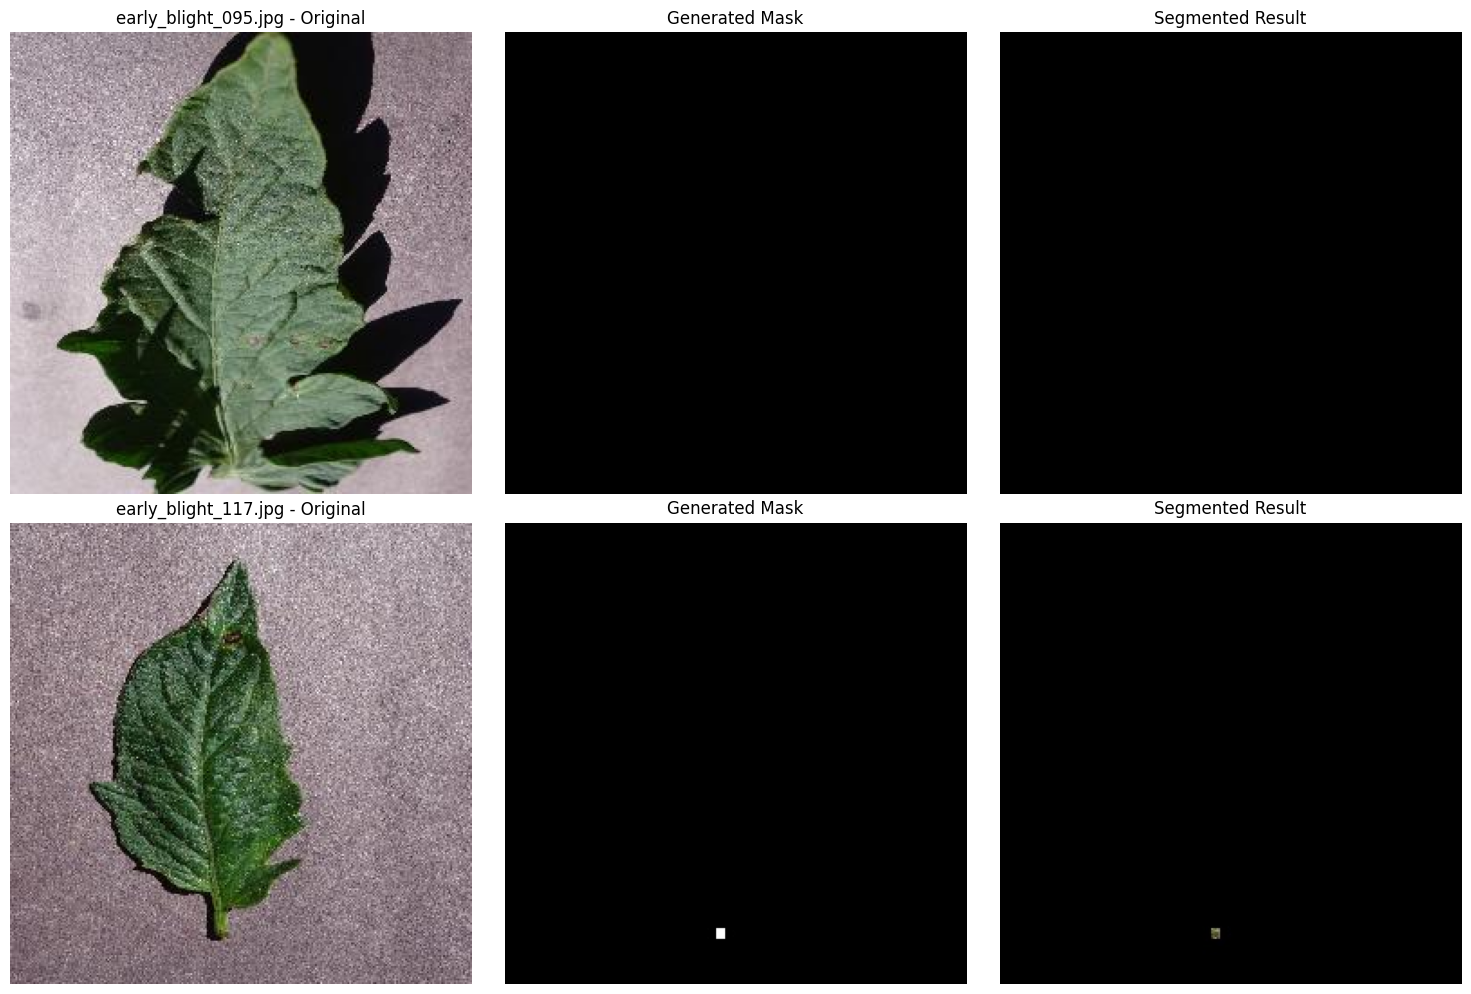

In [17]:
# Failure Case Analysis

# Select two images with segmentation difficulties
failure_samples = [
    "early_blight_095.jpg",
    "early_blight_117.jpg"
]

# Display failure cases
plt.figure(figsize=(15, 10))

for row, filename in enumerate(failure_samples):

    # Read original image
    original = cv2.imread(
        os.path.join(
            input_folder,
            filename
        )
    )

    original = cv2.cvtColor(
        original,
        cv2.COLOR_BGR2RGB
    )

    # Read generated mask
    mask = cv2.imread(
        os.path.join(
            mask_folder,
            filename
        ),
        cv2.IMREAD_GRAYSCALE
    )

    # Read segmented image
    segmented = cv2.imread(
        os.path.join(
            segmented_folder,
            filename
        )
    )

    segmented = cv2.cvtColor(
        segmented,
        cv2.COLOR_BGR2RGB
    )

    # Original image
    plt.subplot(2, 3, row * 3 + 1)
    plt.imshow(original)
    plt.title(filename + " - Original")
    plt.axis("off")

    # Disease mask
    plt.subplot(2, 3, row * 3 + 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Generated Mask")
    plt.axis("off")

    # Segmented image
    plt.subplot(2, 3, row * 3 + 3)
    plt.imshow(segmented)
    plt.title("Segmented Result")
    plt.axis("off")

plt.tight_layout()
plt.show()

Dataset Characteristics

In [15]:
# Dataset Characteristics

# Get all image files
image_files = sorted([
    file for file in os.listdir(input_folder)
    if file.lower().endswith(".jpg")
])

# Store image information
sizes = []
channels = []

for filename in image_files:

    image = cv2.imread(
        os.path.join(
            input_folder,
            filename
        )
    )

    # Get image height, width and channels
    height, width, channel = image.shape

    sizes.append(
        (width, height)
    )

    channels.append(channel)

# Display dataset information
print("Total images:", len(image_files))

print("Image dimensions:")
print("Minimum width:", min(size[0] for size in sizes))
print("Maximum width:", max(size[0] for size in sizes))

print("Minimum height:", min(size[1] for size in sizes))
print("Maximum height:", max(size[1] for size in sizes))

print("Number of channels:", set(channels))

print("Image format: JPG")
print("Image type: Color (RGB/BGR)")

Total images: 120
Image dimensions:
Minimum width: 256
Maximum width: 256
Minimum height: 256
Maximum height: 256
Number of channels: {3}
Image format: JPG
Image type: Color (RGB/BGR)


Affected area analysis cell

Images analysed: 120

Affected leaf area - Final Range [5,40,20] to [35,255,220]
----------------------------------------------------------
Mean affected area      : 18.86 %
Minimum affected area   : 0.00 %
Maximum affected area   : 77.97 %
Standard deviation      : 17.87 %
Images below 1 % area   : 8

HSV range comparison
----------------------------------------------------------
Range                  Mean %         Min %         Max %
Narrow Range             9.92          0.00         53.06
Final Range             18.86          0.00         77.97
Wide Range              27.48          0.83         95.28

Lowest detected area (candidate failure cases):
  early_blight_095.jpg  ->  0.00 %
  early_blight_117.jpg  ->  0.16 %
  early_blight_085.jpg  ->  0.43 %
  early_blight_070.jpg  ->  0.52 %
  early_blight_118.jpg  ->  0.57 %



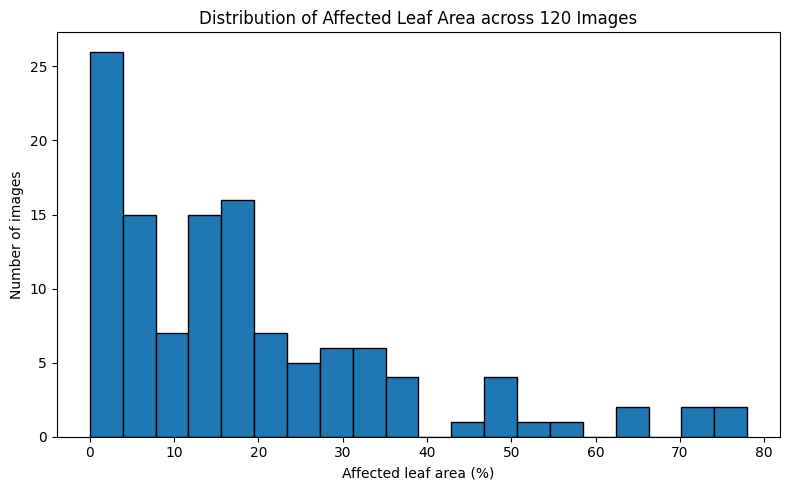

In [16]:
# ============================================================
# Quantitative Analysis: Affected Leaf Area (%)
# Paste this as a new cell after the batch segmentation cell.
# ============================================================

import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

input_folder = "/content/gdrive/MyDrive/Leaf_Disease_Segmentation/Dataset/Tomato_Early_Blight"

# Morphological kernel (same as the main pipeline)
kernel = np.ones((5, 5), np.uint8)

# Saturation floor used to separate the leaf from the grey background.
# The background is nearly neutral grey, so its saturation is close to 0,
# while any leaf tissue (healthy or diseased) is much more saturated.
LEAF_SAT_MIN = 40


def affected_area_percent(hsv_image, lower, upper):
    """Return the percentage of the leaf area selected by the given HSV range."""

    # Leaf region = everything that is not the grey background
    leaf_mask = cv2.inRange(
        hsv_image,
        np.array([0, LEAF_SAT_MIN, 20]),
        np.array([179, 255, 255])
    )

    # Diseased region using the HSV range being tested
    disease_mask = cv2.inRange(hsv_image, lower, upper)

    # Same cleanup as the main pipeline
    disease_mask = cv2.morphologyEx(disease_mask, cv2.MORPH_OPEN, kernel)
    disease_mask = cv2.morphologyEx(disease_mask, cv2.MORPH_CLOSE, kernel)

    # Keep only the diseased pixels that actually lie on the leaf
    disease_mask = cv2.bitwise_and(disease_mask, leaf_mask)

    leaf_pixels = int(np.count_nonzero(leaf_mask))
    disease_pixels = int(np.count_nonzero(disease_mask))

    if leaf_pixels == 0:
        return 0.0

    return (disease_pixels / leaf_pixels) * 100.0


# The three HSV ranges compared in the report
ranges = [
    ("Narrow Range", np.array([8, 50, 30]), np.array([30, 255, 210])),
    ("Final Range",  np.array([5, 40, 20]), np.array([35, 255, 220])),
    ("Wide Range",   np.array([0, 30, 15]), np.array([40, 255, 235])),
]

image_files = sorted([
    file for file in os.listdir(input_folder)
    if file.lower().endswith(".jpg")
])

print("Images analysed:", len(image_files))
print()

results = {}

for name, lower, upper in ranges:

    percentages = []

    for filename in image_files:

        image = cv2.imread(os.path.join(input_folder, filename))
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

        percentages.append(
            affected_area_percent(hsv, lower, upper)
        )

    results[name] = np.array(percentages)


# ---------- Table 1: statistics for the final range ----------
final = results["Final Range"]

print("Affected leaf area - Final Range [5,40,20] to [35,255,220]")
print("-" * 58)
print("Mean affected area      : {:.2f} %".format(final.mean()))
print("Minimum affected area   : {:.2f} %".format(final.min()))
print("Maximum affected area   : {:.2f} %".format(final.max()))
print("Standard deviation      : {:.2f} %".format(final.std()))
print("Images below 1 % area   : {}".format(int((final < 1.0).sum())))
print()

# ---------- Table 2: comparison across the three ranges ----------
print("HSV range comparison")
print("-" * 58)
print("{:<15}{:>14}{:>14}{:>14}".format("Range", "Mean %", "Min %", "Max %"))

for name, _, _ in ranges:
    values = results[name]
    print("{:<15}{:>14.2f}{:>14.2f}{:>14.2f}".format(
        name, values.mean(), values.min(), values.max()
    ))

print()

# ---------- The five images with the smallest detected area ----------
order = np.argsort(final)

print("Lowest detected area (candidate failure cases):")
for index in order[:5]:
    print("  {}  ->  {:.2f} %".format(image_files[index], final[index]))

print()

# ---------- Figure: distribution of affected area ----------
plt.figure(figsize=(8, 5))
plt.hist(final, bins=20, edgecolor="black")
plt.xlabel("Affected leaf area (%)")
plt.ylabel("Number of images")
plt.title("Distribution of Affected Leaf Area across 120 Images")
plt.tight_layout()
plt.show()